In [1]:
import os
import cv2
import numpy as np
import random
import glob

dataset_path = "/content/drive/MyDrive/datasets/test-yolo-2-4-annotations/char_dataset-english-labels-with-less-1"
class_counts = {}

def count_images_per_class():
  for class_name in os.listdir(dataset_path):
      class_path = os.path.join(dataset_path, class_name)
      if os.path.isdir(class_path):
          image_files = [f for f in os.listdir(class_path)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
          class_counts[class_name] = len(image_files)

  print("Current class distribution:")
  for class_name, count in class_counts.items():
      print(f"{class_name}: {count} images")
  return class_counts

def rotate_image_white_padding(image, angle_range=(-10, 10)):
  angle = random.uniform(angle_range[0], angle_range[1])
  rows, cols = image.shape[:2]

  M = cv2.getRotationMatrix2D((cols/2, rows/2), angle, 1)

  rotated = cv2.warpAffine(image, M, (cols, rows), borderValue=(255, 255, 255))

  return rotated

def augment_class(class_name, class_path, current_count):
  print(f"\nProcessing class '{class_name}' with {current_count} images...")

  image_files = glob.glob(os.path.join(class_path, "*.png")) + \
                glob.glob(os.path.join(class_path, "*.jpg")) + \
                glob.glob(os.path.join(class_path, "*.jpeg"))

  if current_count >= 600:
      # Take 30 random images and augment them
      selected_files = random.sample(image_files, min(200, len(image_files)))
      target_augs = 200
      print(f"  Strategy: Augmenting 30 random images from {current_count}")

  elif current_count >= 320:
      # Create 1x copy (same number of augmented images as original)
      target_augs = current_count
      selected_files = image_files.copy()
      print(f"  Strategy: Creating {target_augs} augmented images (1x copy)")

  elif current_count >= 150:
      # Create 3x copy
      target_augs = current_count * 3
      selected_files = image_files * 3
      print(f"  Strategy: Creating {target_augs} augmented images (3x)")

  else:
      # Create 5x copy, targeting ~400 images
      target_augs = max(400, current_count * 5)
      multiplier = target_augs // current_count + 1
      selected_files = image_files * multiplier
      selected_files = selected_files[:target_augs]
      print(f"  Strategy: Creating {target_augs} augmented images (targeting 400+)")

  aug_count = 0
  for i, img_path in enumerate(selected_files):
      try:
          if img_path.lower().endswith('.png'):
              image = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
          else:
              image = cv2.imread(img_path)

          if image is None:
              continue

          # Apply rotation with white padding
          rotated = rotate_image_white_padding(image)

          # Save augmented image
          base_name = os.path.splitext(os.path.basename(img_path))[0]
          ext = os.path.splitext(img_path)[1]
          aug_filename = f"{base_name}_rot_{i}{ext}"
          aug_path = os.path.join(class_path, aug_filename)

          cv2.imwrite(aug_path, rotated)
          aug_count += 1

          if aug_count % 50 == 0:
              print(f"  Processed {aug_count}/{len(selected_files)} images")

      except Exception as e:
          print(f"  Error processing {img_path}: {e}")
          continue

  print(f"  Completed: Added {aug_count} augmented images")
  return aug_count

def augment_dataset():
  count_images_per_class()

  total_added = 0

  for class_name, count in class_counts.items():
      class_path = os.path.join(dataset_path, class_name)

      if not os.path.isdir(class_path):
          continue

      added = augment_class(class_name, class_path, count)
      total_added += added

  print(f"\nAugmentation Completed.")
  print(f"Total images added: {total_added}")

  print("\nFinal class distribution:")
  count_images_per_class()

augment_dataset()

Current class distribution:
khulna: 21 images
sylhet: 7 images
metro: 305 images
lo: 204 images
no: 38 images
to: 22 images
maimanshing: 7 images
po: 12 images
tto: 7 images
ko: 18 images
ga: 217 images
cho: 40 images
bo: 29 images
kho: 14 images
ho: 186 images
gha: 17 images
chattro: 74 images
9: 329 images
do: 14 images
dhaka: 333 images
4: 424 images
1: 612 images
0: 408 images
2: 446 images
6: 368 images
8: 411 images
3: 413 images
7: 416 images
5: 413 images

Processing class 'khulna' with 21 images...
  Strategy: Creating 400 augmented images (targeting 400+)
  Processed 50/400 images
  Processed 100/400 images
  Processed 150/400 images
  Processed 200/400 images
  Processed 250/400 images
  Processed 300/400 images
  Processed 350/400 images
  Processed 400/400 images
  Completed: Added 400 augmented images

Processing class 'sylhet' with 7 images...
  Strategy: Creating 400 augmented images (targeting 400+)
  Processed 50/400 images
  Processed 100/400 images
  Processed 150/4

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import cv2
from PIL import Image
import pandas as pd
import os

# random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

dataset_path = "/content/drive/MyDrive/datasets/test-yolo-2-4-annotations/char_dataset-english-labels-with-less-1"
img_size = (64, 64)
batch_size = 32
model = None
class_names = []
history = None

def preprocess_contour_image(img):
    # Since we already preprocessed the images
    # we just need to:
    # 1. Load as grayscale
    # 2. Convert to 3-channel for EfficientNet compatibility
    # 3. Normalize to [0, 1]

    if len(img.shape) == 3:
        # If RGB, convert to grayscale first
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    img = cv2.resize(img, img_size)

    # Convert single channel to 3-channel for EfficientNet
    img_3ch = np.stack([img, img, img], axis=-1)

    return img_3ch

def load_and_preprocess_data():
    global class_names  # Make class_names a global variable
    class_names = sorted([d for d in os.listdir(dataset_path)
                              if os.path.isdir(os.path.join(dataset_path, d))])

    print(f"Found {len(class_names)} classes: {class_names}")

    images = []
    labels = []

    for class_idx, class_name in enumerate(class_names):
        class_path = os.path.join(dataset_path, class_name)
        image_files = [f for f in os.listdir(class_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        print(f"Loading {len(image_files)} images from class '{class_name}'")

        for img_file in image_files:
            img_path = os.path.join(class_path, img_file)
            try:
                # Load image (your images are already grayscale from contour extraction)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    # Applying the same preprocessing as in my pipeline
                    img = preprocess_contour_image(img)
                    images.append(img)
                    labels.append(class_idx)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")

    # Converting to numpy arrays and normalize
    images = np.array(images, dtype=np.float32) / 255.0
    labels = np.array(labels)

    print(f"Total images loaded: {len(images)}")
    print(f"Image shape: {images.shape}")
    print(f"Labels shape: {labels.shape}")

    return images, labels

def create_data_generators(X_train, y_train, X_val, y_val):
    """Create data generators with augmentation"""

    # Data augmentation for training - optimized for binary text images
    train_datagen = ImageDataGenerator(
        rotation_range=5,  # Reduced rotation for text
        width_shift_range=0.05,  # Reduced shifts for precise character positioning
        height_shift_range=0.05,
        shear_range=0.05,  # Reduced shear for text
        zoom_range=0.05,  # Reduced zoom for text
        horizontal_flip=False,  # Never flip text
        fill_mode='constant',  # Use constant fill (white background)
        cval=1.0,  # Fill with white (since normalized to [0,1])
        # Remove brightness and channel shift as these are binary images
    )

    # No augmentation for validation
    val_datagen = ImageDataGenerator()

    # Converting labels to categorical
    y_train_cat = keras.utils.to_categorical(y_train, num_classes=len(class_names))
    y_val_cat = keras.utils.to_categorical(y_val, num_classes=len(class_names))

    train_generator = train_datagen.flow(
        X_train, y_train_cat,
        batch_size=batch_size,
        shuffle=True
    )

    val_generator = val_datagen.flow(
        X_val, y_val_cat,
        batch_size=batch_size,
        shuffle=False
    )

    return train_generator, val_generator, y_train_cat, y_val_cat

def build_model():
    """Build the CNN model using EfficientNet-B0 as base"""
    print("Building model...")

    global model # Make model a global variable

    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(img_size[0], img_size[1], 3), # Corrected input_shape
        pooling='avg'
    )

    base_model.trainable = False

    model = keras.Sequential([
        base_model,
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(len(class_names), activation='softmax')
    ])

    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy'] # Removed 'top_2_accuracy'
    )

    print(f"Model built with {len(class_names)} output classes")
    return model

def train_model(train_generator, val_generator, epochs=35):
    """Train the model with callbacks"""
    print("Starting training...")

    global history # Make history a global variable

    callbacks = [
        EarlyStopping(
            monitor='val_accuracy',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=5,
            min_lr=1e-7,
            verbose=1
        ),
        ModelCheckpoint(
            'best_bengali_ocr_model.h5',
            monitor='val_accuracy',
            save_best_only=True,
            save_weights_only=False,
            verbose=1
        )
    ]

    history = model.fit(
        train_generator,
        epochs=epochs,
        validation_data=val_generator,
        callbacks=callbacks,
        verbose=1
    )

    fine_tune_model(train_generator, val_generator)

    return history

def fine_tune_model(train_generator, val_generator, fine_tune_epochs=65):
    # Unfreezing the base model
    model.layers[0].trainable = True

    # Recompile with lower learning rate
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy'] # Removed 'top_2_accuracy'
    )

    fine_tune_history = model.fit(
        train_generator,
        epochs=fine_tune_epochs,
        validation_data=val_generator,
        callbacks=[
            EarlyStopping(
                monitor='val_accuracy',
                patience=5,
                restore_best_weights=True
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=3,
                min_lr=1e-8,
                verbose=1
            )
        ],
        verbose=1
    )

    # Appending fine-tuning history
    for key in history.history.keys():
        history.history[key].extend(fine_tune_history.history[key])


def evaluate_model(X_test, y_test):
    print("Evaluating model...")

    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)

    test_accuracy = np.mean(y_pred == y_test)
    print(f"Test Accuracy: {test_accuracy:.4f}")

    print("\nClassification Report:")
    report = classification_report(y_test, y_pred, target_names=class_names)
    print(report)

    plot_confusion_matrix(y_test, y_pred)

    # Per-class accuracy
    plot_per_class_accuracy(y_test, y_pred)

    return test_accuracy, y_pred, y_pred_prob

def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

def plot_per_class_accuracy(y_true, y_pred):
    per_class_acc = []
    for i, class_name in enumerate(class_names):
        mask = y_true == i
        if np.sum(mask) > 0:
            acc = np.mean(y_pred[mask] == y_true[mask])
            per_class_acc.append(acc)
        else:
            per_class_acc.append(0)

    plt.figure(figsize=(15, 6))
    bars = plt.bar(range(len(class_names)), per_class_acc)
    plt.xlabel('Classes')
    plt.ylabel('Accuracy')
    plt.title('Per-Class Accuracy')
    plt.xticks(range(len(class_names)), class_names, rotation=45)
    plt.ylim(0, 1)

    for bar, acc in zip(bars, per_class_acc):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{acc:.3f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

def plot_training_history():
    """Plot training history"""
    if history is None:
        print("No training history available")
        return

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Accuracy
    axes[0, 0].plot(history.history['accuracy'], label='Training Accuracy')
    axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0, 0].set_title('Model Accuracy')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # Loss
    axes[0, 1].plot(history.history['loss'], label='Training Loss')
    axes[0, 1].plot(history.history['val_loss'], label='Validation Loss')
    axes[0, 1].set_title('Model Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # Top-2 Accuracy (if available)
    if 'top_2_accuracy' in history.history:
        axes[1, 0].plot(history.history['top_2_accuracy'], label='Training Top-2 Accuracy')
        axes[1, 0].plot(history.history['val_top_2_accuracy'], label='Validation Top-2 Accuracy')
        axes[1, 0].set_title('Top-2 Accuracy')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Top-2 Accuracy')
        axes[1, 0].legend()
        axes[1, 0].grid(True)
    else:
        axes[1, 0].text(0.5, 0.5, 'Top-2 Accuracy\nNot Available',
                      ha='center', va='center', transform=axes[1, 0].transAxes)

    if 'lr' in history.history:
        axes[1, 1].plot(history.history['lr'])
        axes[1, 1].set_title('Learning Rate')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Learning Rate')
        axes[1, 1].set_yscale('log')
        axes[1, 1].grid(True)
    else:
        axes[1, 1].text(0.5, 0.5, 'Learning Rate\nNot Available',
                      ha='center', va='center', transform=axes[1, 1].transAxes)

    plt.tight_layout()
    plt.show()


def predict_sample_images(X_test, y_test, num_samples=10):
    indices = np.random.choice(len(X_test), num_samples, replace=False)

    sample_images = X_test[indices]
    sample_labels = y_test[indices]
    predictions = model.predict(sample_images)
    predicted_classes = np.argmax(predictions, axis=1)


    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.ravel()

    for i in range(num_samples):
        axes[i].imshow(sample_images[i])
        axes[i].set_title(f'True: {class_names[sample_labels[i]]}\n'
                        f'Pred: {class_names[predicted_classes[i]]}\n'
                        f'Conf: {predictions[i][predicted_classes[i]]:.3f}')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

Loading and preprocessing data...
Found 29 classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'bo', 'chattro', 'cho', 'dhaka', 'do', 'ga', 'gha', 'ho', 'kho', 'khulna', 'ko', 'lo', 'maimanshing', 'metro', 'no', 'po', 'sylhet', 'to', 'tto']
Loading 816 images from class '0'
Loading 812 images from class '1'
Loading 892 images from class '2'
Loading 826 images from class '3'
Loading 848 images from class '4'
Loading 826 images from class '5'
Loading 736 images from class '6'
Loading 832 images from class '7'
Loading 822 images from class '8'
Loading 658 images from class '9'
Loading 429 images from class 'bo'
Loading 474 images from class 'chattro'
Loading 440 images from class 'cho'
Loading 666 images from class 'dhaka'
Loading 414 images from class 'do'
Loading 868 images from class 'ga'
Loading 417 images from class 'gha'
Loading 744 images from class 'ho'
Loading 414 images from class 'kho'
Loading 421 images from class 'khulna'
Loading 418 images from class 'ko'
Loading 816

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,415,680 (16.84 MB)

 Trainable params: 365,341 (1.39 MB)

...

401/401 ━━━━━━━━━━━━━━━━━━━━ 22s 54ms/step - accuracy: 0.1308 - loss: 3.0440 - val_accuracy: 0.3089 - val_loss: 2.7103 - learning_rate: 2.0000e-04
Epoch 43/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1322 - loss: 3.0496
Epoch 43: val_accuracy improved from 0.30893 to 0.32095, saving model to best_bengali_ocr_model.h5


401/401 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 0.1322 - loss: 3.0496 - val_accuracy: 0.3209 - val_loss: 2.6991 - learning_rate: 2.0000e-04
Epoch 44/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.1303 - loss: 3.0545
Epoch 44: val_accuracy did not improve from 0.32095
401/401 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 0.1303 - loss: 3.0545 - val_accuracy: 0.3104 - val_loss: 2.7053 - learning_rate: 2.0000e-04
Epoch 45/50
400/401 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.1328 - loss: 3.0425
Epoch 45: val_accuracy improved from 0.32095 to 0.33370, saving model to best_bengali_ocr_model.h5


401/401 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.1328 - loss: 3.0425 - val_accuracy: 0.3337 - val_loss: 2.6942 - learning_rate: 2.0000e-04
Epoch 46/50
400/401 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1268 - loss: 3.0426
Epoch 46: val_accuracy improved from 0.33370 to 0.34171, saving model to best_bengali_ocr_model.h5


401/401 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 0.1268 - loss: 3.0426 - val_accuracy: 0.3417 - val_loss: 2.6867 - learning_rate: 2.0000e-04
Epoch 47/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1297 - loss: 3.0581
Epoch 47: val_accuracy did not improve from 0.34171
401/401 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.1297 - loss: 3.0581 - val_accuracy: 0.3162 - val_loss: 2.6885 - learning_rate: 2.0000e-04
Epoch 48/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1369 - loss: 3.0516
Epoch 48: val_accuracy did not improve from 0.34171
401/401 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - accuracy: 0.1369 - loss: 3.0516 - val_accuracy: 0.2958 - val_loss: 2.6953 - learning_rate: 2.0000e-04
Epoch 49/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1302 - loss: 3.0609
Epoch 49: val_accuracy did not improve from 0.34171
401/401 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - accuracy: 0.1302 - loss: 3.0609 - val_accuracy: 0.3169 - val_loss: 2.7020 - learning_rate: 2.0

401/401 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.1322 - loss: 3.0546 - val_accuracy: 0.3421 - val_loss: 2.6989 - learning_rate: 2.0000e-04
Restoring model weights from the end of the best epoch: 50.

Fine-tuning the model...
Epoch 1/65
401/401 ━━━━━━━━━━━━━━━━━━━━ 157s 188ms/step - accuracy: 0.0986 - loss: 3.2843 - val_accuracy: 0.0740 - val_loss: 3.6409 - learning_rate: 1.0000e-05
Epoch 2/65
401/401 ━━━━━━━━━━━━━━━━━━━━ 26s 65ms/step - accuracy: 0.1902 - loss: 2.8152 - val_accuracy: 0.1577 - val_loss: 3.0158 - learning_rate: 1.0000e-05
Epoch 3/65
401/401 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.2516 - loss: 2.6188 - val_accuracy: 0.2867 - val_loss: 2.6043 - learning_rate: 1.0000e-05
Epoch 4/65
401/401 ━━━━━━━━━━━━━━━━━━━━ 27s 67ms/step - accuracy: 0.3011 - loss: 2.4741 - val_accuracy: 0.3169 - val_loss: 2.5277 - learning_rate: 1.0000e-05
Epoch 5/65
401/401 ━━━━━━━━━━━━━━━━━━━━ 26s 65ms/step - accuracy: 0.3317 - loss: 2.3738 - val_accuracy: 0.3971 - val_loss: 2.4008 - l

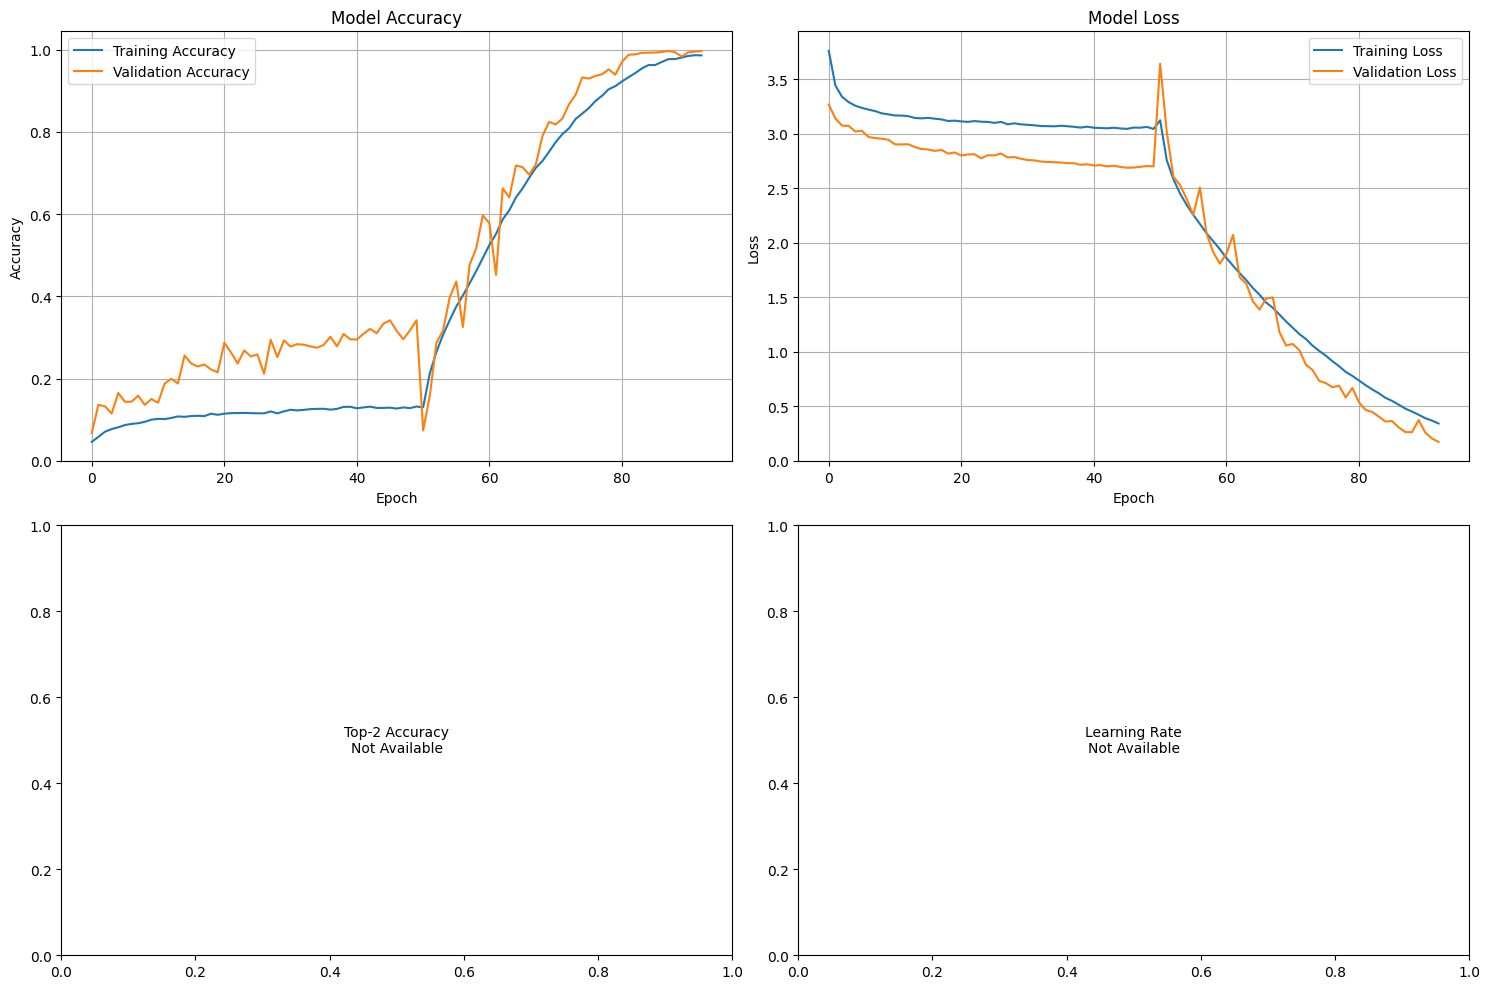

Evaluating model...
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 101ms/step
Test Accuracy: 0.9942

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       123
           1       0.97      0.96      0.96       122
           2       0.98      0.98      0.98       134
           3       0.99      1.00      1.00       124
           4       1.00      1.00      1.00       127
           5       1.00      1.00      1.00       124
           6       1.00      1.00      1.00       111
           7       0.99      1.00      1.00       125
           8       0.99      1.00      1.00       124
           9       0.98      0.99      0.98        99
          bo       1.00      1.00      1.00        64
     chattro       0.99      1.00      0.99        71
         cho       1.00      0.95      0.98        66
       dhaka       1.00      0.99      0.99       100
          do       0.97      1.00      0.98        62
          ga       1.00    

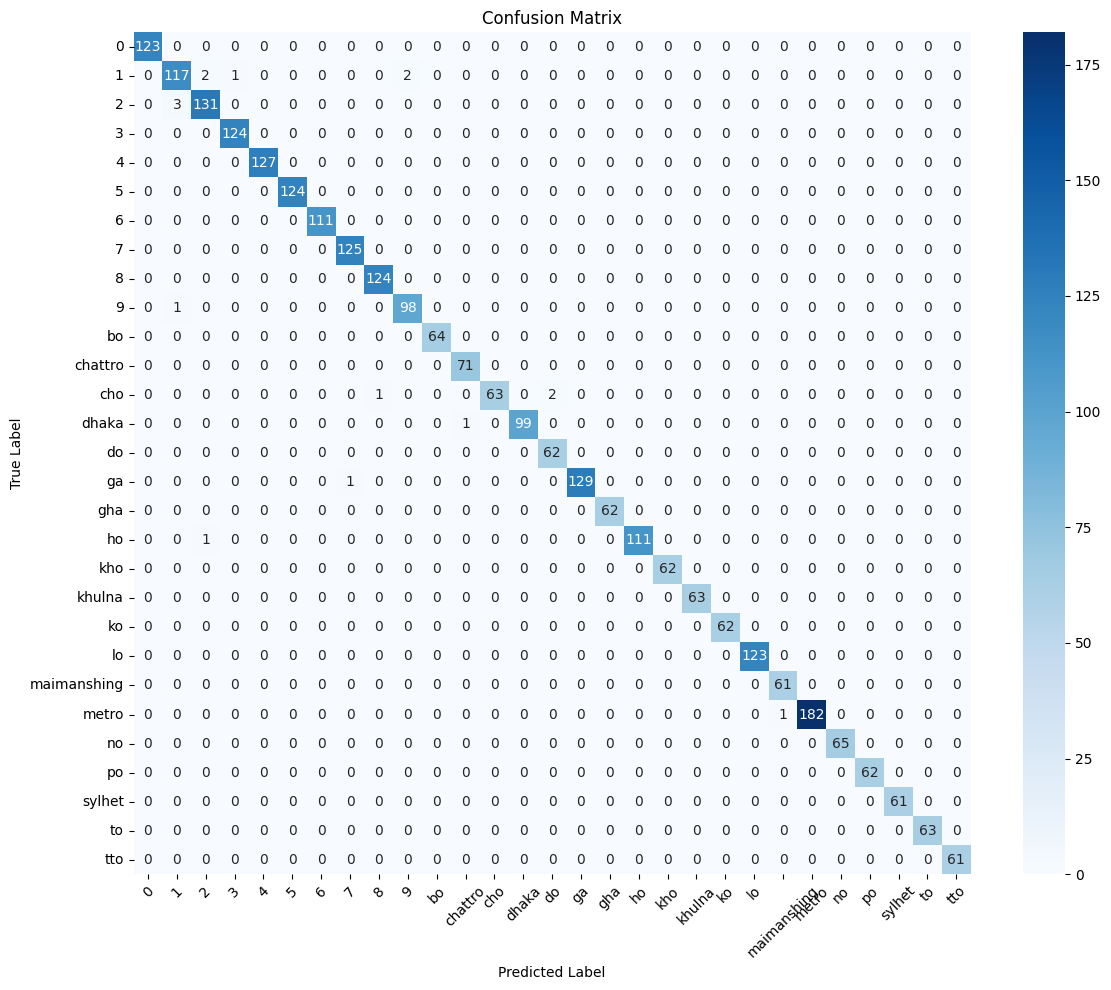

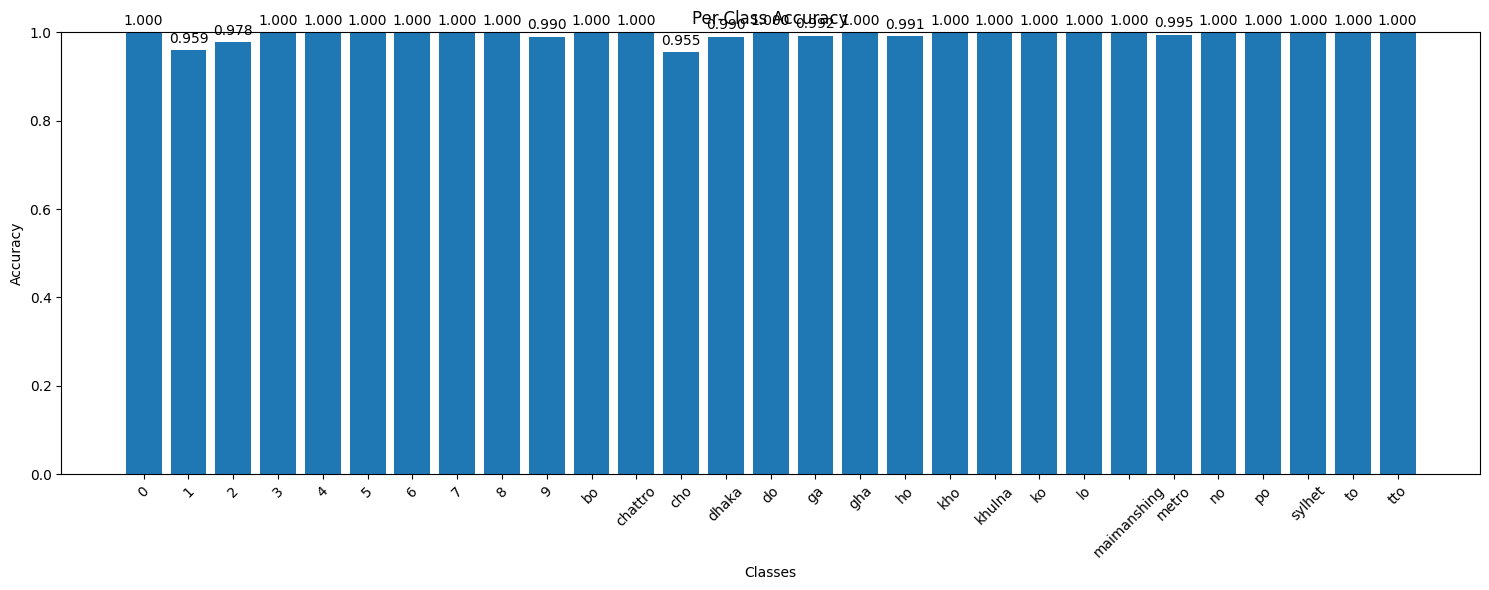

test accuracy:  0.9941733430444283


In [5]:
images, labels = load_and_preprocess_data()

X_train, X_temp, y_train, y_temp = train_test_split(
    images, labels, test_size=0.3, random_state=42, stratify=labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")


train_gen, val_gen, y_train_cat, y_val_cat = create_data_generators(
    X_train, y_train, X_val, y_val
)


build_model()
model.summary()

history = train_model(train_gen, val_gen, epochs=50)

plot_training_history()

test_accuracy, y_pred, y_pred_prob = evaluate_model(X_test, y_test)

print("test accuracy: ", test_accuracy)

In [ ]:
model.save('/content/drive/MyDrive/datasets/test-yolo-2-4-annotations/EfficientNetB0_license_plate_v2.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


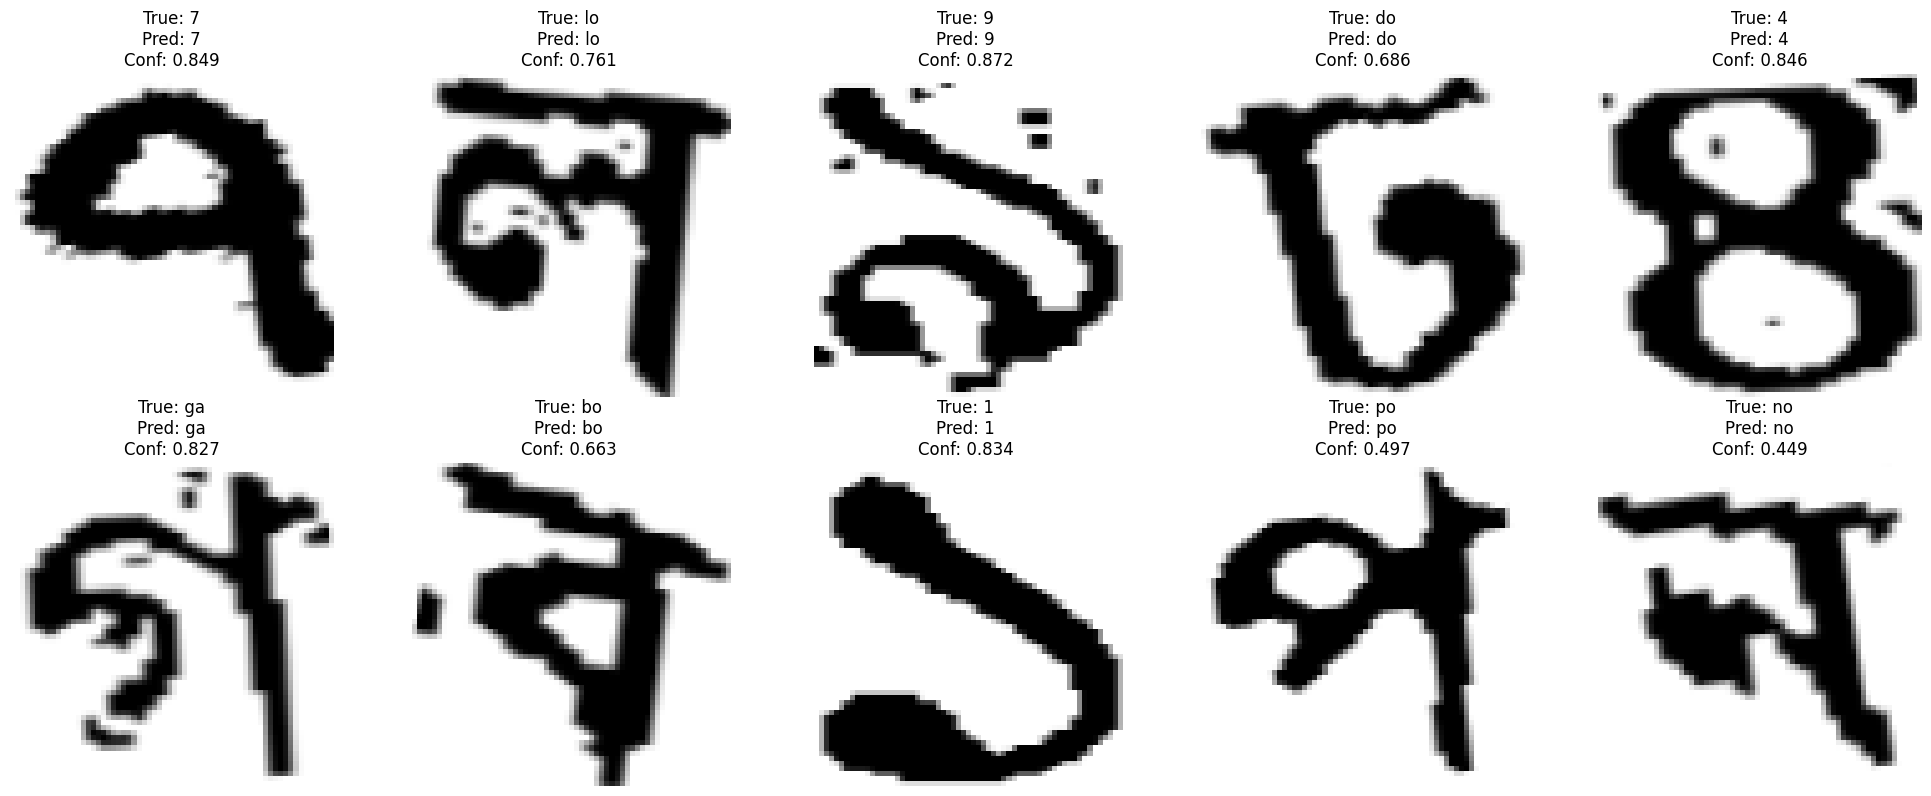

In [6]:
predict_sample_images(X_test, y_test, num_samples=10)